Category Wise Sales



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
df = pd.read_excel("../database/Sample-Superstore.csv.xlsx")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06 00:00:00,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales.plot(kind="bar")
plt.title("Category-wise Sales")
plt.ylabel("Total Sales")
plt.xlabel("Category")
plt.show()

Profit by Category


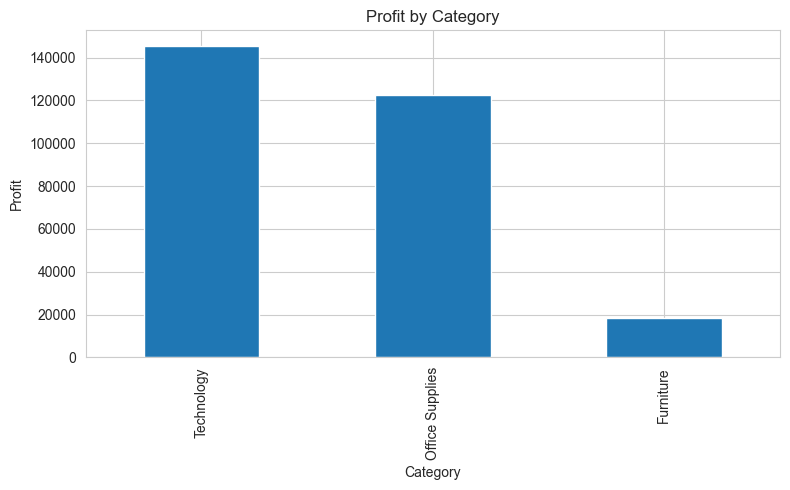

In [4]:
category_profit = (
    df.groupby('Category')['Profit']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category_profit.plot(
    kind='bar'
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()

plt.show()

Sales by Region

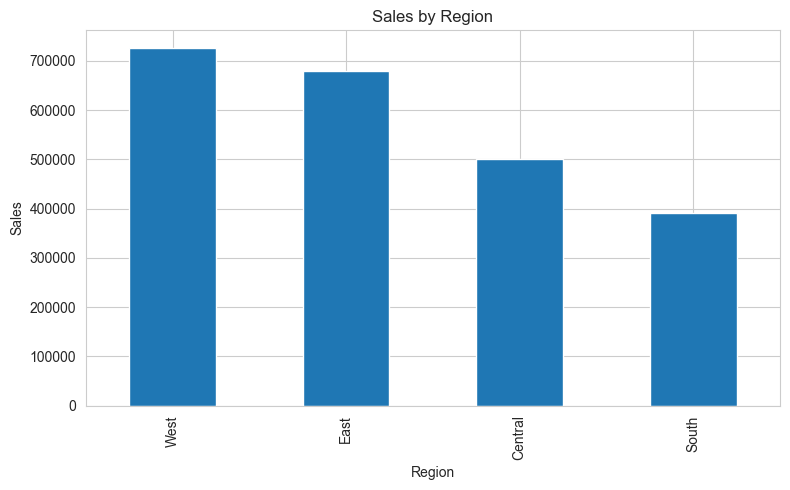

In [6]:
region_sales = (
    df.groupby('Region')['Sales']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

region_sales.plot(
    kind='bar'
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()

plt.show()

PIE CHART — SALES DISTRIBUTION 



In [ ]:
plt.figure(figsize=(7,7))

plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%')
plt.title("Sales Distribution by Category")
plt.show()

MONTHLY SALES TREND

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.plot(monthly_sales.index, monthly_sales.values)
plt.xticks(rotation=90)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

TOP 10 CUSTOMERS

In [ ]:
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind="barh")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer Name")
plt.gca().invert_yaxis()
plt.show()

REGION / STATE WISE SALES

In [ ]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales.plot(kind="bar")
plt.title("Region-wise Sales")
plt.ylabel("Sales")
plt.show()

Top 10 Loss Making Products

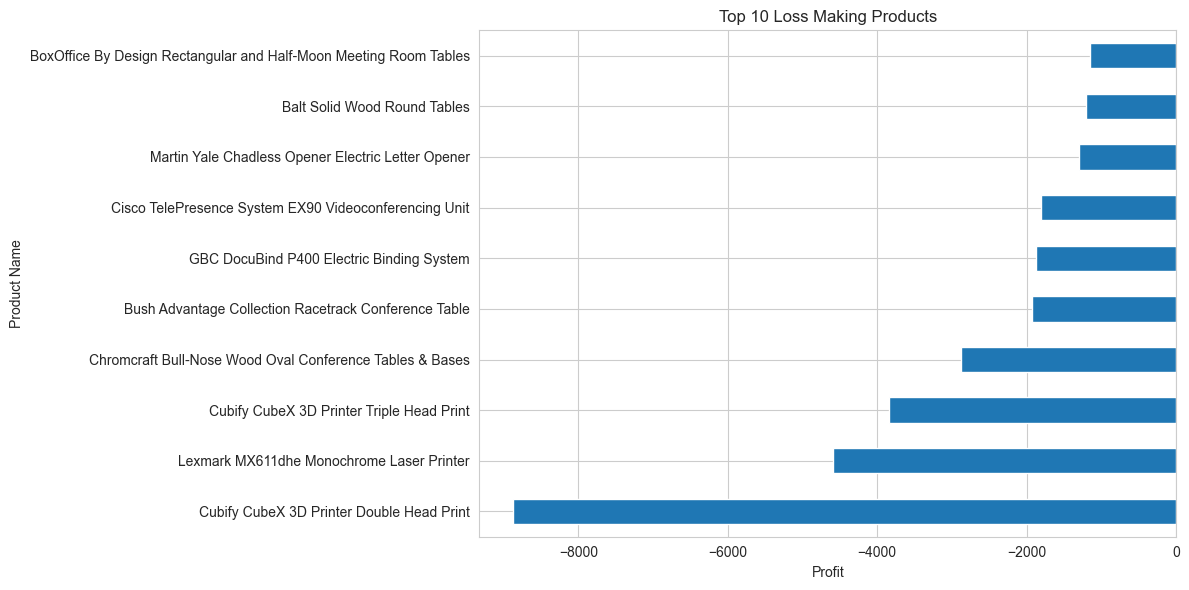

In [7]:
loss_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values()
      .head(10)
)

plt.figure(figsize=(12,6))

loss_products.plot(
    kind='barh'
)

plt.title("Top 10 Loss Making Products")
plt.xlabel("Profit")

plt.tight_layout()

plt.show()

PROFIT vs DISCOUNT

In [ ]:
plt.scatter(df["Discount"], df["Profit"], alpha=0.5)
plt.title("Discount vs Profit Relationship")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()